In [1]:
file_path="D:/Wia/Code(My)/data_scaling_skewed_data.csv"

In [2]:
import pandas as pd
df=pd.read_csv(file_path)

In [3]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25.0,68.22,26401.83,5.13,68.46
1,2,2.99,25.0,72.62,29899.43,10.14,58.53
2,3,2.76,24.0,87.15,84956.82,6.63,50.72
3,4,2.76,20.0,87.14,15797.16,0.99,72.44
4,5,9.30,18.0,87.15,44019.48,2.10,60.92


In [4]:
df.isna()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False


In [5]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     4
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [19]:
df["Age"] = df["Age"].fillna(df["Age"].mode())

In [20]:
df.head(14)

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,avg_learning_rate(hr),pass_fail
0,1,4.79,25.00000,68.22,26401.83,5.13,68.46,0.069968,True
1,2,2.99,25.00000,72.62,29899.43,10.14,58.53,0.051085,False
2,3,2.76,24.00000,87.15,84956.82,6.63,50.72,0.054416,False
3,4,2.76,20.00000,87.14,15797.16,0.99,72.44,0.038100,True
4,5,9.30,18.00000,87.15,44019.48,2.10,60.92,0.152659,True
5,6,5.73,25.00000,100.00,22427.13,0.48,52.93,0.108256,False
6,7,2.26,18.00000,87.71,22116.67,10.78,62.24,0.036311,True
7,8,4.94,25.00000,82.64,72323.12,3.26,57.02,0.086636,False
8,9,4.00,21.00000,91.54,56549.67,0.91,90.25,0.044321,True
9,10,0.43,20.00000,88.51,55946.92,3.90,80.58,0.005336,True


In [8]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [9]:
marks_col = ["Study_Hours", "Internet_Usage_Hours", "Exam_Score"]
corr_matrix=df[marks_col].corr()
corr_matrix

,Study_Hours,Internet_Usage_Hours,Exam_Score
Study_Hours,1.000000,-0.020783,0.069318
Internet_Usage_Hours,-0.020783,1.000000,0.109160
Exam_Score,0.069318,0.109160,1.000000


<Axes: >

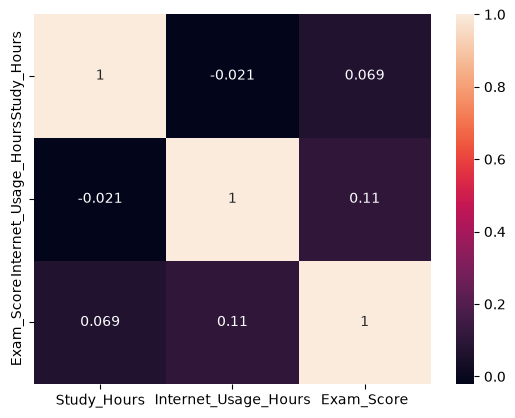

In [10]:
import seaborn as sns
sns.heatmap(corr_matrix, annot=True)

In [11]:
df["avg_learning_rate(hr)"] = df["Study_Hours"]/df["Exam_Score"]
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,avg_learning_rate(hr)
0,1,4.79,25.0,68.22,26401.83,5.13,68.46,0.069968
1,2,2.99,25.0,72.62,29899.43,10.14,58.53,0.051085
2,3,2.76,24.0,87.15,84956.82,6.63,50.72,0.054416
3,4,2.76,20.0,87.14,15797.16,0.99,72.44,0.038100
4,5,9.30,18.0,87.15,44019.48,2.10,60.92,0.152659


In [51]:
df["Pass"] = df["Exam_Score"]>60
df.head(10)

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,avg_learning_rate(hr),pass_fail,Pass
0,1,4.79,25.0,68.22,26401.83,5.13,68.46,0.069968,True,True
1,2,2.99,25.0,72.62,29899.43,10.14,58.53,0.051085,False,False
2,3,2.76,24.0,87.15,84956.82,6.63,50.72,0.054416,False,False
3,4,2.76,20.0,87.14,15797.16,0.99,72.44,0.038100,True,True
4,5,9.30,18.0,87.15,44019.48,2.10,60.92,0.152659,True,True
5,6,5.73,25.0,100.00,22427.13,0.48,52.93,0.108256,False,False
6,7,2.26,18.0,87.71,22116.67,10.78,62.24,0.036311,True,True
7,8,4.94,25.0,82.64,72323.12,3.26,57.02,0.086636,False,False
8,9,4.00,21.0,91.54,56549.67,0.91,90.25,0.044321,True,True
9,10,0.43,20.0,88.51,55946.92,3.90,80.58,0.005336,True,True


In [54]:
df=df.drop(columns="pass_fail")

In [55]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())
df.head(10)

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,avg_learning_rate(hr),Pass
0,1,4.79,25.0,68.22,26401.83,5.13,68.46,0.069968,True
1,2,2.99,25.0,72.62,29899.43,10.14,58.53,0.051085,False
2,3,2.76,24.0,87.15,84956.82,6.63,50.72,0.054416,False
3,4,2.76,20.0,87.14,15797.16,0.99,72.44,0.038100,True
4,5,9.30,18.0,87.15,44019.48,2.10,60.92,0.152659,True
5,6,5.73,25.0,100.00,22427.13,0.48,52.93,0.108256,False
6,7,2.26,18.0,87.71,22116.67,10.78,62.24,0.036311,True
7,8,4.94,25.0,82.64,72323.12,3.26,57.02,0.086636,False
8,9,4.00,21.0,91.54,56549.67,0.91,90.25,0.044321,True
9,10,0.43,20.0,88.51,55946.92,3.90,80.58,0.005336,True


In [56]:
df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(df["Internet_Usage_Hours"].mean())
df.head(10)

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,avg_learning_rate(hr),Pass
0,1,4.79,25.0,68.22,26401.83,5.13,68.46,0.069968,True
1,2,2.99,25.0,72.62,29899.43,10.14,58.53,0.051085,False
2,3,2.76,24.0,87.15,84956.82,6.63,50.72,0.054416,False
3,4,2.76,20.0,87.14,15797.16,0.99,72.44,0.038100,True
4,5,9.30,18.0,87.15,44019.48,2.10,60.92,0.152659,True
5,6,5.73,25.0,100.00,22427.13,0.48,52.93,0.108256,False
6,7,2.26,18.0,87.71,22116.67,10.78,62.24,0.036311,True
7,8,4.94,25.0,82.64,72323.12,3.26,57.02,0.086636,False
8,9,4.00,21.0,91.54,56549.67,0.91,90.25,0.044321,True
9,10,0.43,20.0,88.51,55946.92,3.90,80.58,0.005336,True


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

trf1 = ColumnTransformer([("imput_numerical", SimpleImputer(strategy="mean"),["Internet_Usage_Hours"])],
                         remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

In [33]:
trf2 =ColumnTransformer([("impute_numerical", SimpleImputer(strategy="most_frequent"),["Age"])], remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin

class Ratio(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x):
        x["study_internet_ratio"]=x["Study_Hours"]/x["Internet_Usage_Hours"]
        return x
    

In [46]:
from sklearn.preprocessing import OneHotEncoder
trf3 = ColumnTransformer([("ohe", OneHotEncoder(sparse_output=False),["Pass"])],
                      remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

In [81]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler
trf4=ColumnTransformer([
    ("scaling",MinMaxScaler(), ["Family_Income"])]
                       , remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

In [83]:
from sklearn.pipeline import Pipeline
pipe=Pipeline([
    ("trans1", trf1),
    ("trans2", trf2),
    ("study_internet_ratio", Ratio()),
    ("trans3", trf3),
    ("trans4", trf4)
])


In [84]:
pipe

D:\Anaconda_app\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trans1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imput_numerical',
                                                  SimpleImputer(),
                                                  ['Internet_Usage_Hours'])],
                                   verbose_feature_names_out=False)),
                ('trans2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_numerical',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age'])],
                                   verbose_feature_names_out=False)),
                ('study_internet_ratio', Ratio()),
                ('trans3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Pass'])],
                                   verbose_feature_names_out=False)),
                ('trans4',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', MinMaxScaler(),
                                                  ['Family_Income'])],
                                   verbose_feature_names_out=False))])

In [85]:
df_transform = pipe.fit_transform(df)
df_transform

,Family_Income,Pass_False,Pass_True,Age,Internet_Usage_Hours,Student_ID,Study_Hours,Attendance,Exam_Score,avg_learning_rate(hr),study_internet_ratio
0,0.118586,0.0,1.0,25.0,5.13,1,4.79,68.22,68.46,0.069968,0.933723
1,0.137082,1.0,0.0,25.0,10.14,2,2.99,72.62,58.53,0.051085,0.294872
2,0.428245,1.0,0.0,24.0,6.63,3,2.76,87.15,50.72,0.054416,0.416290
3,0.062505,0.0,1.0,20.0,0.99,4,2.76,87.14,72.44,0.038100,2.787879
4,0.211754,0.0,1.0,18.0,2.10,5,9.30,87.15,60.92,0.152659,4.428571
...,...,...,...,...,...,...,...,...,...,...,...
95,0.412418,1.0,0.0,25.0,1.02,96,1.81,88.30,43.47,0.041638,1.774510
96,0.012842,0.0,1.0,18.0,4.37,97,10.84,73.71,72.83,0.148840,2.480549
97,0.061920,0.0,1.0,18.0,7.90,98,4.71,76.40,79.25,0.059432,0.596203
98,0.121910,1.0,0.0,20.0,2.51,99,1.40,89.47,52.26,0.026789,0.557769


In [58]:
cols = df.columns.tolist()
cols

['Student_ID',
 'Study_Hours',
 'Age',
 'Attendance',
 'Family_Income',
 'Internet_Usage_Hours',
 'Exam_Score',
 'avg_learning_rate(hr)',
 'Pass']

In [80]:
from scipy.stats import skew
for col in cols:
    print(f"{col} skew value")
    print(skew(df[col]-1))

Student_ID skew value
0.0
Study_Hours skew value
1.4445515769053525
Age skew value
-0.07293637793641278
Attendance skew value
-0.2783973884122492
Family_Income skew value
2.2085748430929804
Internet_Usage_Hours skew value
1.4664141347002972
Exam_Score skew value
0.0379853363995778
avg_learning_rate(hr) skew value
1.6926330959138458
Pass skew value
-1.0943058062101276


<Figure size 500x600 with 0 Axes>

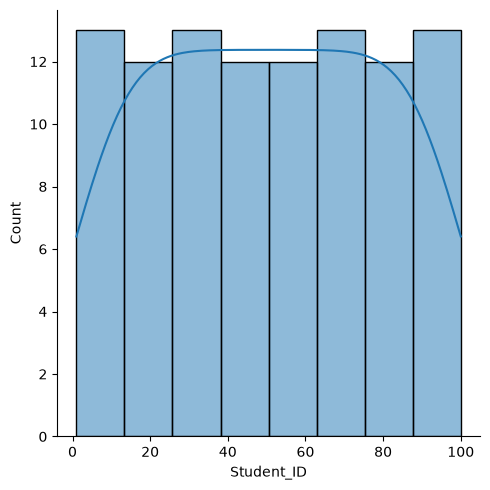

<Figure size 500x600 with 0 Axes>

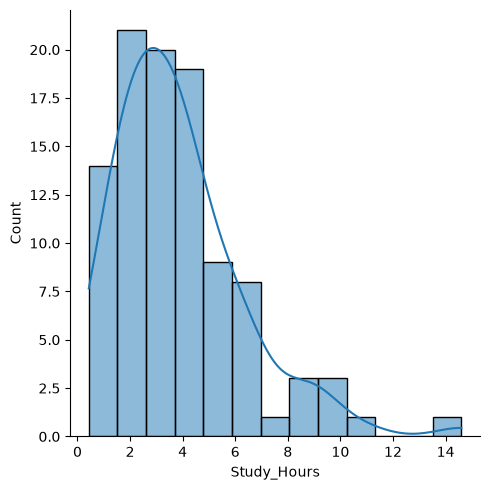

<Figure size 500x600 with 0 Axes>

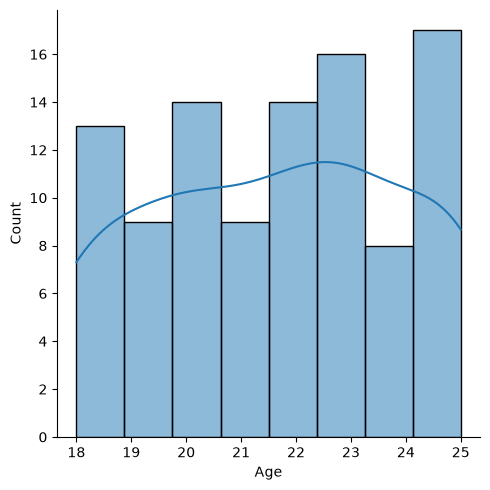

<Figure size 500x600 with 0 Axes>

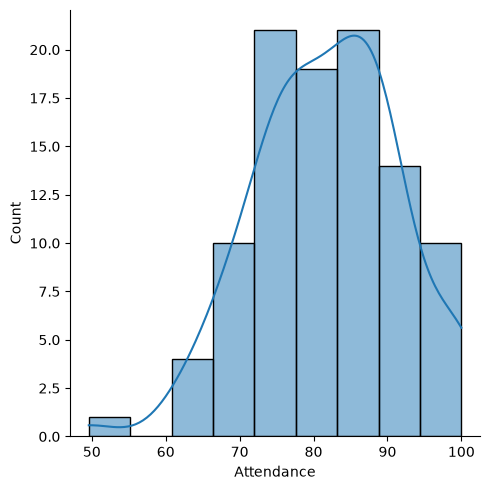

<Figure size 500x600 with 0 Axes>

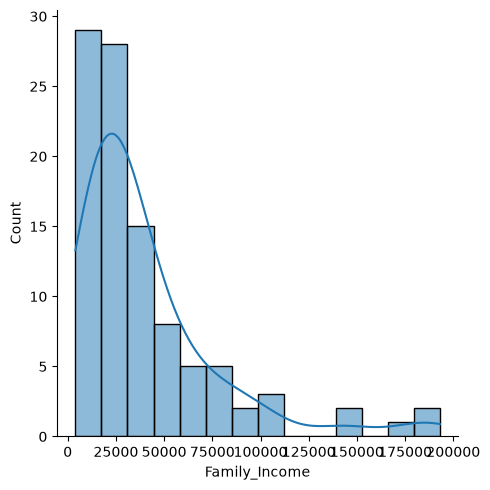

<Figure size 500x600 with 0 Axes>

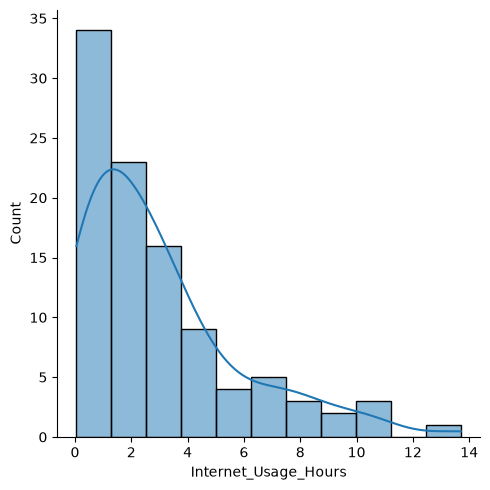

<Figure size 500x600 with 0 Axes>

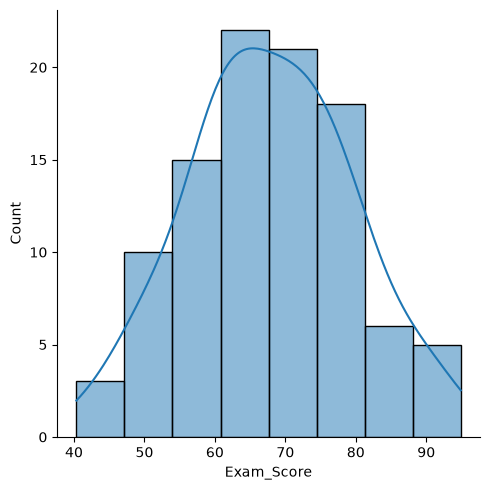

<Figure size 500x600 with 0 Axes>

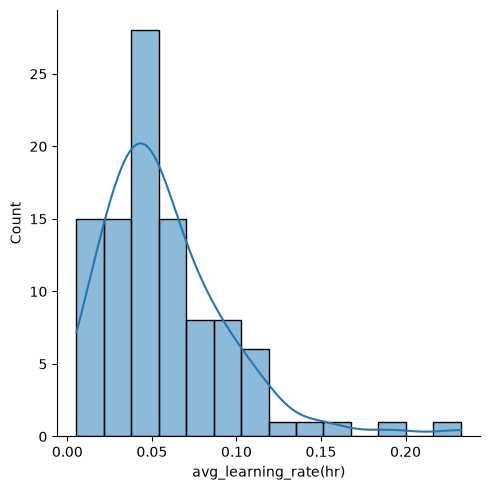

<Figure size 500x600 with 0 Axes>

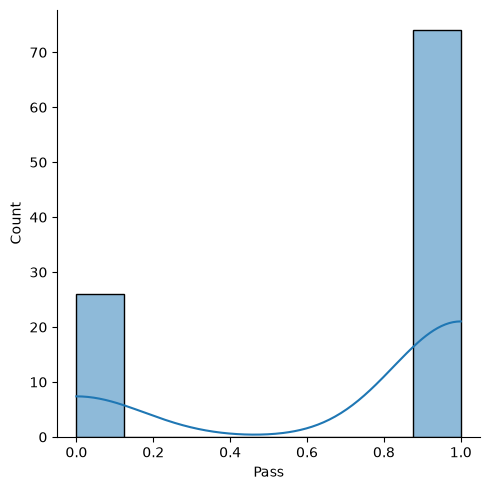

In [76]:
from matplotlib.figure import SubFigure
import matplotlib.pyplot as plt
import seaborn as sns
for col in cols:
    plt.figure(figsize=(5,6))
    sns.displot(df[col],kde=True)
    plt.show()

yeojohnson Transformation
0.7170160232640321
After log transform of Student_ID
-0.27165883857045336


<Figure size 600x400 with 0 Axes>

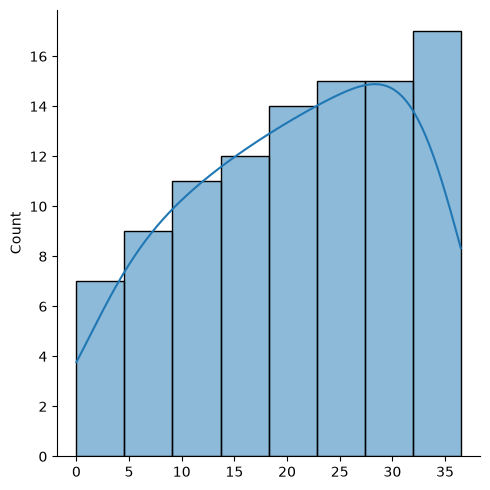

0.2643231457464551
After log transform of Study_Hours
0.007656715424845711


<Figure size 600x400 with 0 Axes>

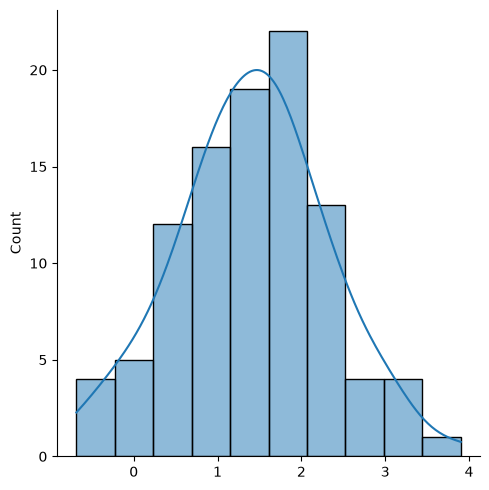

1.1662652583564723
After log transform of Age
-0.051635508587868015


<Figure size 600x400 with 0 Axes>

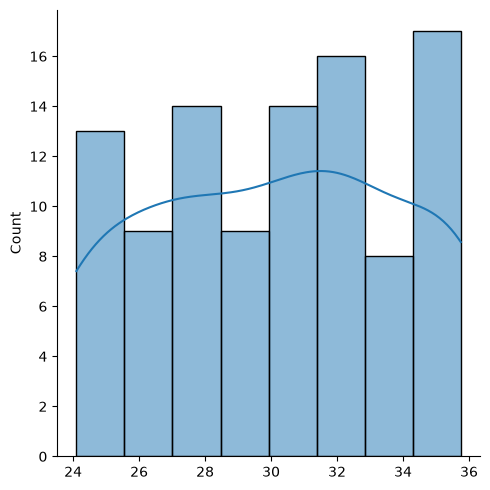

1.7348339854870376
After log transform of Attendance
-0.008614391513295374


<Figure size 600x400 with 0 Axes>

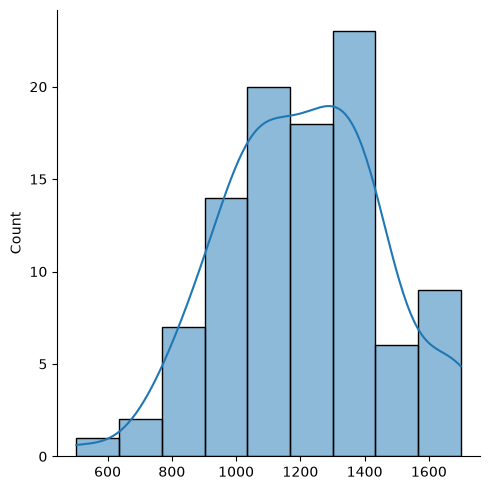

-0.09037328289439239
After log transform of Family_Income
0.005049632560797063


<Figure size 600x400 with 0 Axes>

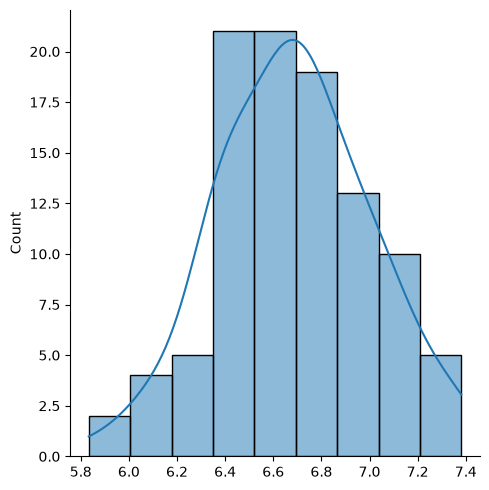

0.149081057694217
After log transform of Internet_Usage_Hours
0.03693616467384258


<Figure size 600x400 with 0 Axes>

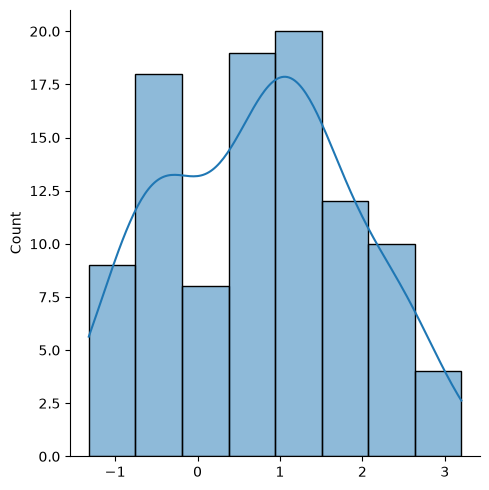

0.8671204652664792
After log transform of Exam_Score
-0.01836384638608002


<Figure size 600x400 with 0 Axes>

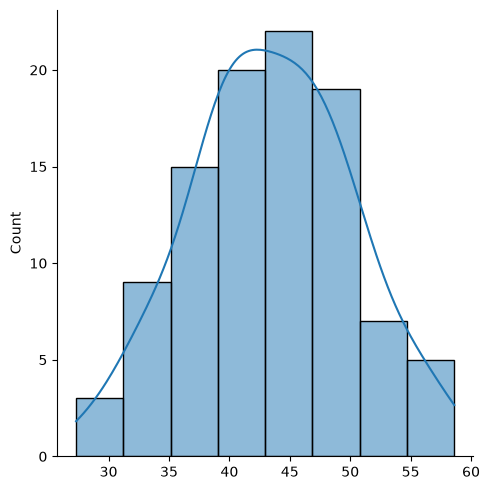

-23.291373786985528
After log transform of avg_learning_rate(hr)
0.10147436916066303


<Figure size 600x400 with 0 Axes>

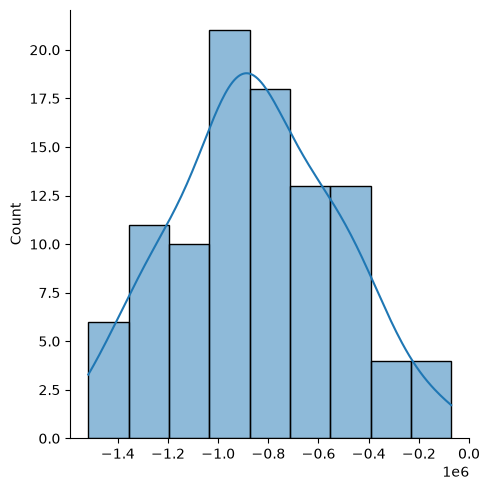

6.893589148587421
After log transform of Pass
-1.0943058062101283


<Figure size 600x400 with 0 Axes>

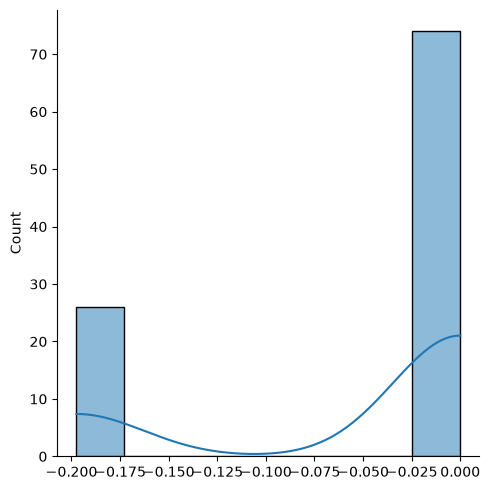

In [86]:
from scipy.stats import yeojohnson 
print("yeojohnson Transformation")
for col in cols:
    data,l=yeojohnson(df[col]-1)
    print(l)
    print(f"After transform of {col}")
    s=skew(data)
    print(s)
    plt.figure(figsize=(6,4))
    sns.displot(data, kde=True)
    plt.show()